Targeting folder: E:\Reverse Telescope Test Data\20260306_data\springgenie\springgenie_fits
Searching for: E:\Reverse Telescope Test Data\20260306_data\springgenie\springgenie_fits\*.fits
✅ Found 14150 files. Ready to start.
Starting analysis on 14150 files...
Processed 0/14150 (0.0 files/s)
Processed 500/14150 (6.1 files/s)
Processed 1000/14150 (6.4 files/s)
Processed 1500/14150 (6.4 files/s)
Processed 2000/14150 (6.4 files/s)
Processed 2500/14150 (6.5 files/s)
Processed 3000/14150 (6.4 files/s)
Processed 3500/14150 (6.4 files/s)
Processed 4000/14150 (6.4 files/s)
Processed 4500/14150 (6.4 files/s)
Processed 5000/14150 (6.4 files/s)
Processed 5500/14150 (6.4 files/s)
Processed 6000/14150 (6.4 files/s)
Processed 6500/14150 (6.4 files/s)
Processed 7000/14150 (6.4 files/s)
Processed 7500/14150 (6.4 files/s)
Processed 8000/14150 (6.4 files/s)
Processed 8500/14150 (6.4 files/s)
Processed 9000/14150 (6.4 files/s)
Processed 9500/14150 (6.4 files/s)
Processed 10000/14150 (6.4 files/s)
Process

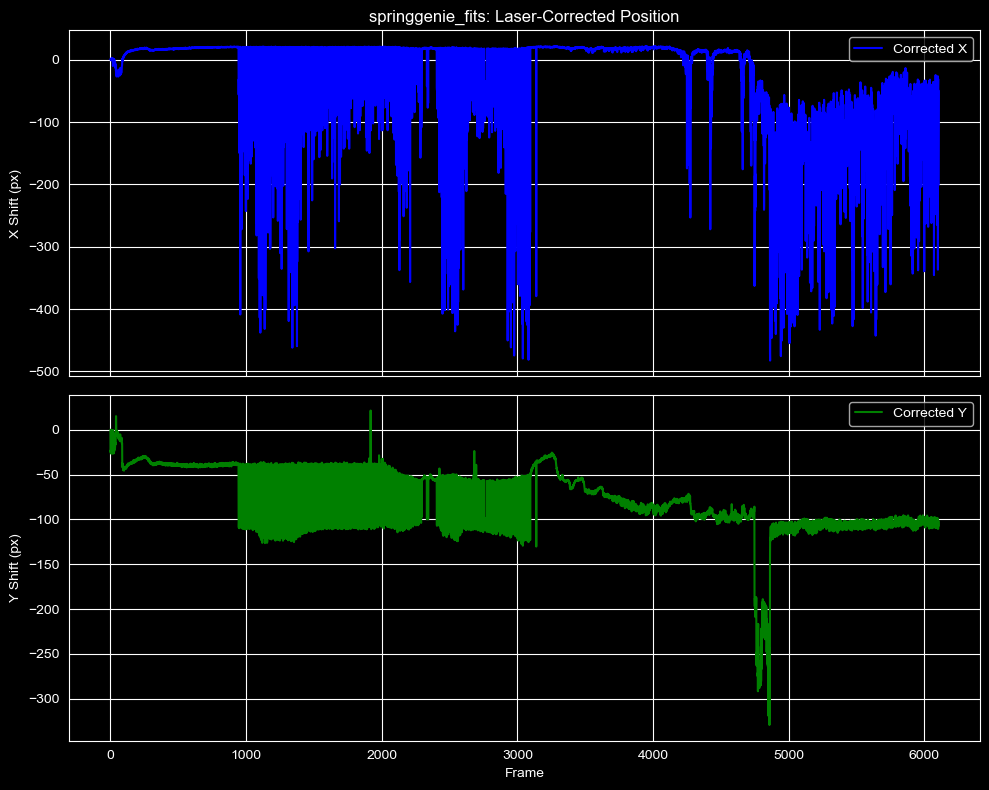

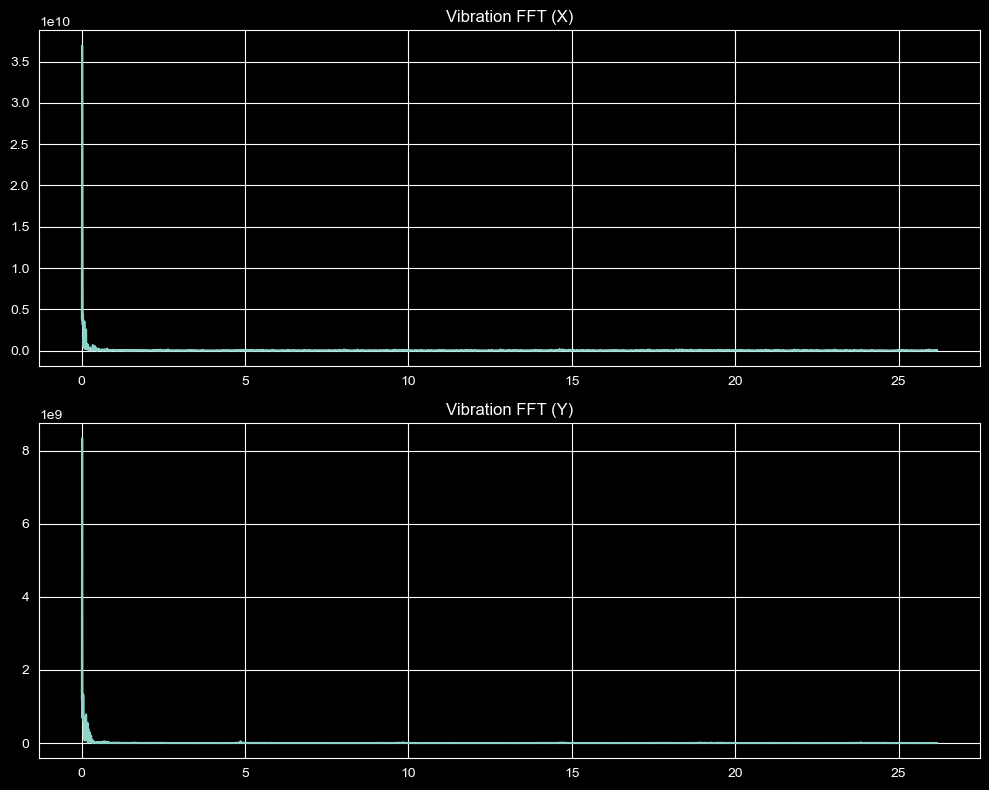

✅ Data saved to: E:\Reverse Telescope Test Data\20260306_data\springgenie\collimated_beam_entry.xlsx


In [1]:
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import time
from pathlib import Path
# Added for parallel processing to speed up the loop
from concurrent.futures import ThreadPoolExecutor

#  PATHS
target_folder = r"E:\Reverse Telescope Test Data\20260306_data\springgenie\springgenie_fits"

# Clean up path
target_folder = target_folder.strip('"')
print(f"Targeting folder: {target_folder}")

# Search
search_path = os.path.join(target_folder, "*.fits")
print(f"Searching for: {search_path}")

# Files
fits_list = glob.glob(search_path)
fits_list = np.sort(fits_list)

if len(fits_list) == 0:
    print("❌ ERROR: No files found.")
    try:
        print("\nHere is what I found in that folder:")
        print(os.listdir(target_folder))
    except:
        print("I could not even open the folder.")
    raise SystemExit("Stopping: Check file path.")
else:
    print(f"✅ Found {len(fits_list)} files. Ready to start.")

# Derive folder name for saving files later
# This grabs the folder name from your path automatically
foldername = os.path.basename(os.path.dirname(search_path)) 
parent_folder = os.path.dirname(target_folder) # Save results one level up

# DEFINITIONS & COORDINATES
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-0.5 * ((x - mu)/sigma)**2) + offset

# Worker function so we can run multiple files at once
def analyze_single_frame(filename):
    """Opens one file, runs math, returns results. Returns NaNs if failed."""
    dx, dy, dfx, dfy, lx, ly = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    try:
        with fits.open(filename) as hdul:
            img = np.flip(hdul[0].data, axis=(0, 1))

        # Dot Fit
        roi_dot = img[dot_y_slice, dot_x_slice]
        px = np.sum(roi_dot, axis=0)
        py = np.sum(roi_dot, axis=1)
        try:
            popt, _ = curve_fit(gaussian, np.arange(px.size), px, p0=[px.max(), px.argmax(), 5, np.median(px)])
            dx = popt[1] + dot_x_slice.start
            dfx = abs(popt[2]) * 2.355
            
            popt, _ = curve_fit(gaussian, np.arange(py.size), py, p0=[py.max(), py.argmax(), 5, np.median(py)])
            dy = popt[1] + dot_y_slice.start
            dfy = abs(popt[2]) * 2.355
        except: pass

        # Laser Fit
        roi_las = img[laser_y_slice, laser_x_slice]
        pxl = np.sum(roi_las, axis=0)
        pyl = np.sum(roi_las, axis=1)
        try:
            popt, _ = curve_fit(gaussian, np.arange(pxl.size), pxl, p0=[pxl.max(), pxl.argmax(), 20, np.median(pxl)])
            lx = popt[1] + laser_x_slice.start
            
            popt, _ = curve_fit(gaussian, np.arange(pyl.size), pyl, p0=[pyl.max(), pyl.argmax(), 20, np.median(pyl)])
            ly = popt[1] + laser_y_slice.start
        except: pass
        
    except: pass
    return (dx, dy, dfx, dfy, lx, ly)

# COORDINATES (Change for respective images using next code block)
dot_x_slice = slice(1400, 1500) 
dot_y_slice = slice(580, 660)

laser_x_slice = slice(1100, 1700)
laser_y_slice = slice(750, 1300)
use_laser = True 

# STREAMING ANALYSIS
print(f"Starting analysis on {len(fits_list)} files...")
start_time = time.time()

# Replaced the slow loop with ThreadPoolExecutor (Parallel Processing)
results = []
# max_workers=16 allows 16 files to load/process simultaneously
with ThreadPoolExecutor(max_workers=16) as executor:
    # Map the worker function to the file list
    for i, res in enumerate(executor.map(analyze_single_frame, fits_list)):
        results.append(res)
        if i % 500 == 0:
            elapsed = time.time() - start_time
            rate = i / (elapsed + 1e-9)
            print(f"Processed {i}/{len(fits_list)} ({rate:.1f} files/s)")

# Unpack the results from the parallel loop back into arrays
results = np.array(results)
dot_x = results[:, 0]
dot_y = results[:, 1]
dot_fwhm_x = results[:, 2]
dot_fwhm_y = results[:, 3]
laser_x = results[:, 4]
laser_y = results[:, 5]
saved_data_location = Path(parent_folder) / f"{Path(parent_folder).name}_data.csv"
np.savetxt(saved_data_location, results, delimiter=",", header="dot_x,dot_y,dot_fwhm_x,dot_fwhm_y,laser_x,laser_y", comments="")

# CALCULATE SUBTRACTION
# Filter bad data
mask = np.isfinite(dot_x) & np.isfinite(dot_y) & np.isfinite(laser_x) & np.isfinite(laser_y)

# SUBTRACT LASER DRIFT
corrected_x_raw = dot_x[mask] - laser_x[mask]
corrected_y_raw = dot_y[mask] - laser_y[mask]

# Recenter to 0
# Check to ensure we actually have data before accessing index [0]
if len(corrected_x_raw) > 0:
    mu_x_rel = corrected_x_raw - corrected_x_raw[0]
    mu_y_rel = corrected_y_raw - corrected_y_raw[0]
else:
    print("❌ ERROR: Math failed. All frames were bad.")
    raise SystemExit("Stopping.")

# Filter FWHM to match
fwhm_x_final = dot_fwhm_x[mask]
fwhm_y_final = dot_fwhm_y[mask]
frames = np.arange(len(mu_x_rel))

print("✅ Calculations Complete.")

# PLOTTING
# Plot 1: Position
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axs[0].plot(frames, mu_x_rel, color='blue', label="Corrected X")
axs[0].set_ylabel("X Shift (px)"); axs[0].legend()
axs[0].set_title(f"{foldername}: Laser-Corrected Position")
axs[1].plot(frames, mu_y_rel, color='green', label="Corrected Y")
axs[1].set_ylabel("Y Shift (px)"); axs[1].set_xlabel("Frame"); axs[1].legend()
plt.tight_layout()
# Save Plot 1
save_plot_pos = os.path.join(parent_folder, foldername + "_position.png")
fig.savefig(save_plot_pos)
plt.show()

# Plot 2: FFT
def compute_fft(signal, dt):
    fft_vals = np.fft.fft(signal - np.mean(signal))
    freqs = np.fft.fftfreq(len(signal), d=dt)
    mask = freqs > 0
    return freqs[mask], np.abs(fft_vals[mask])**2

frame_rate = 52.37   # CHECK THIS NUMBER
dt = 1.0 / frame_rate

freqs_x, power_mu_x   = compute_fft(mu_x_rel, dt)
freqs_y, power_mu_y   = compute_fft(mu_y_rel, dt)

fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(freqs_x, power_mu_x)
axs[0].set_title("Vibration FFT (X)")
axs[1].plot(freqs_y, power_mu_y)
axs[1].set_title("Vibration FFT (Y)")
plt.tight_layout()

# Save Plot 2
save_plot_fft = os.path.join(parent_folder, foldername + "_FFT.png")
fig.savefig(save_plot_fft)
plt.show()

# SAVE TO EXCEL
# Saves to the parent folder (one level up from _fits)
csv_path = os.path.join(parent_folder, "collimated_beam_entry.xlsx")

try:
    df = pd.read_excel(csv_path, engine='openpyxl')
except:
    df = pd.DataFrame()

# Using os.path.basename to get safe filenames
try:
    first_file = os.path.basename(fits_list[0])
    # Fixed the cut-off line
    last_file = os.path.basename(fits_list[-1])
    
    start_t = first_file[-22:-5]
    stop_t = last_file[-22:-5]
except:
    start_t = "Unknown"
    stop_t = "Unknown"

new_row = {
    'filename': foldername,
    'frames': len(frames),
    'frame rate': frame_rate,
    'x pos (px)': np.nanmean(mu_x_rel),
    'x std (px)': np.nanstd(mu_x_rel),
    'y pos (px)': np.nanmean(mu_y_rel),
    'y std (px)': np.nanstd(mu_y_rel),
    'FWHM x': np.nanmean(fwhm_x_final),
    'FWHM y': np.nanmean(fwhm_y_final)
}

df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
try:
    df.to_excel(csv_path, index=False, engine='openpyxl')
    print(f"✅ Data saved to: {csv_path}")
except:
    print("❌ ERROR: Close the Excel file and try again.")

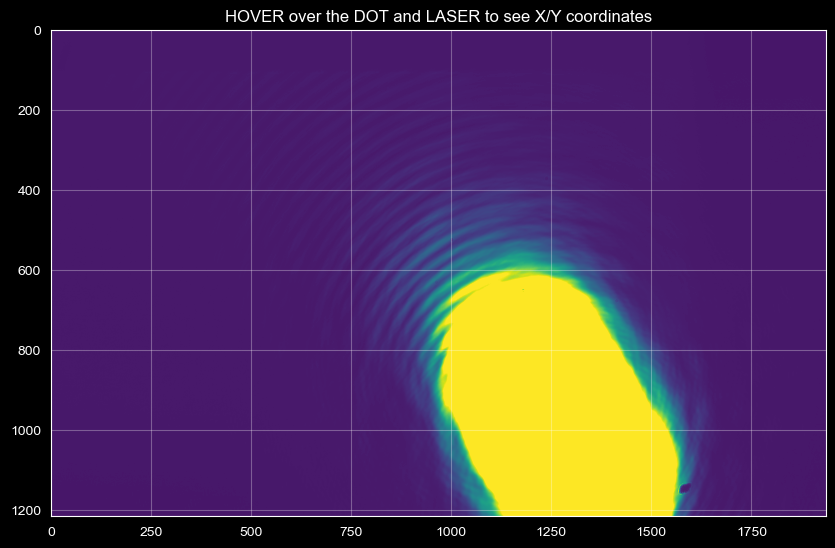

In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

# Load the first file from your list
with fits.open(fits_list[0]) as hdul:
    data = np.flip(hdul[0].data, axis=(0, 1)) # Flip to match your analysis code

# Plot it so you can find the coordinates for slice
plt.figure(figsize=(10, 10))
plt.imshow(data, cmap='viridis', vmin=0, vmax=np.percentile(data, 99))
plt.title("HOVER over the DOT and LASER to see X/Y coordinates")
plt.grid(True, color='white', alpha=0.3)
plt.show()

✅ Found existing data in memory. Processing now...
✅ Data Cleaned. Removed 0 glitch frames.


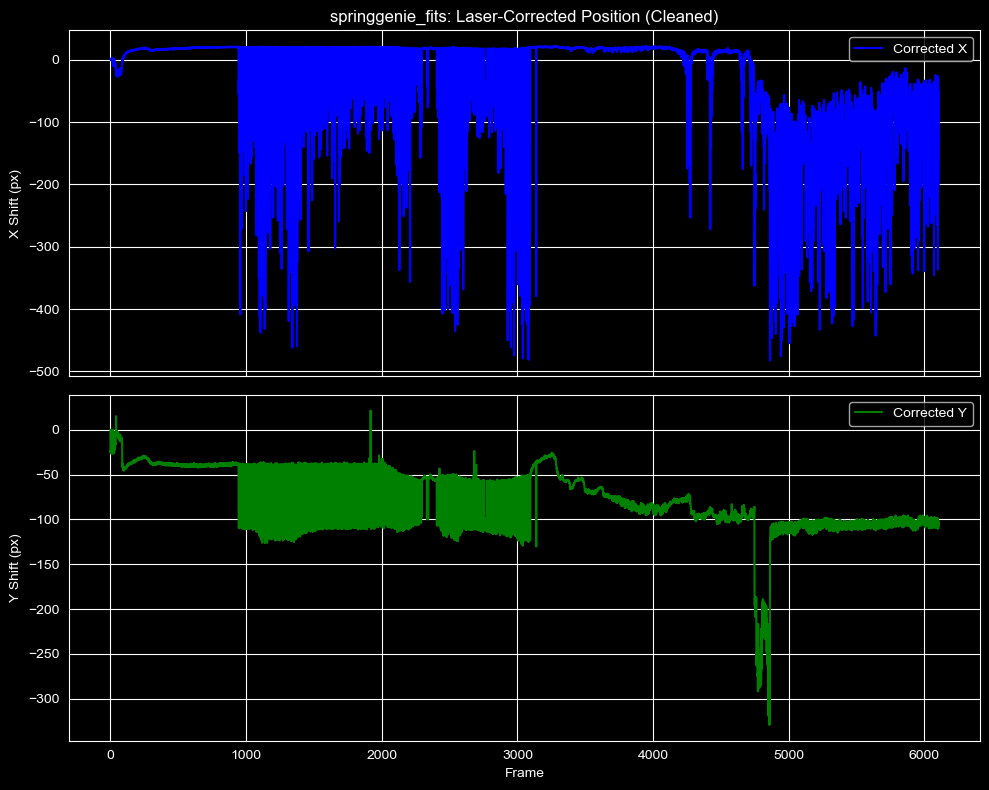

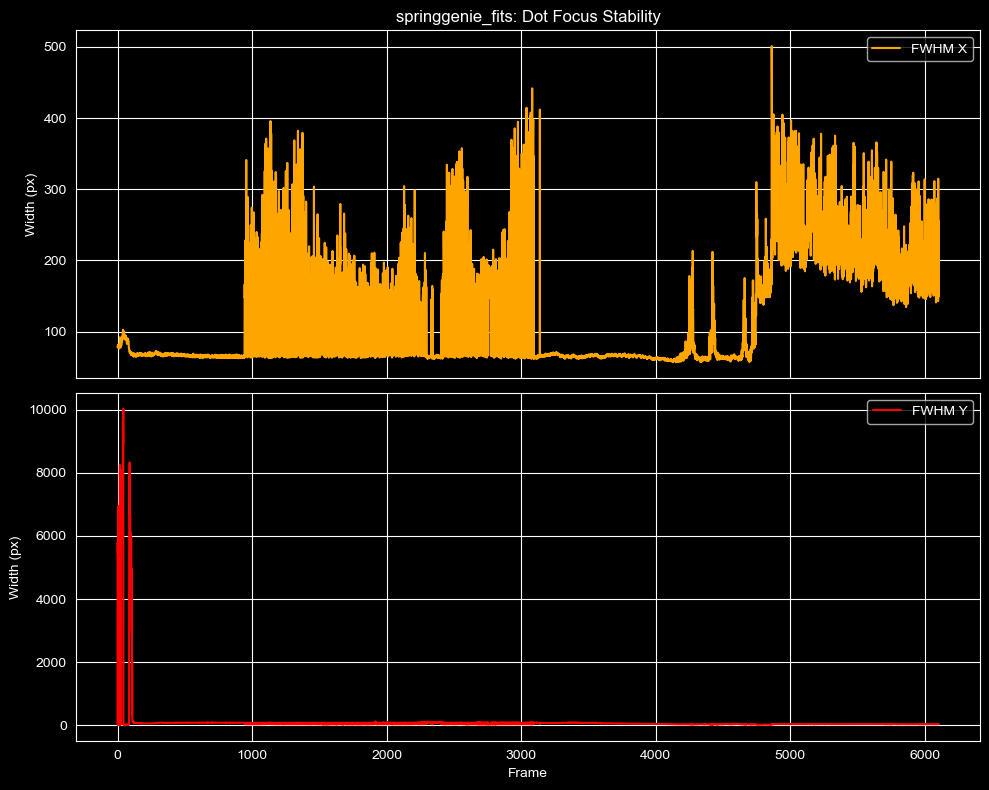

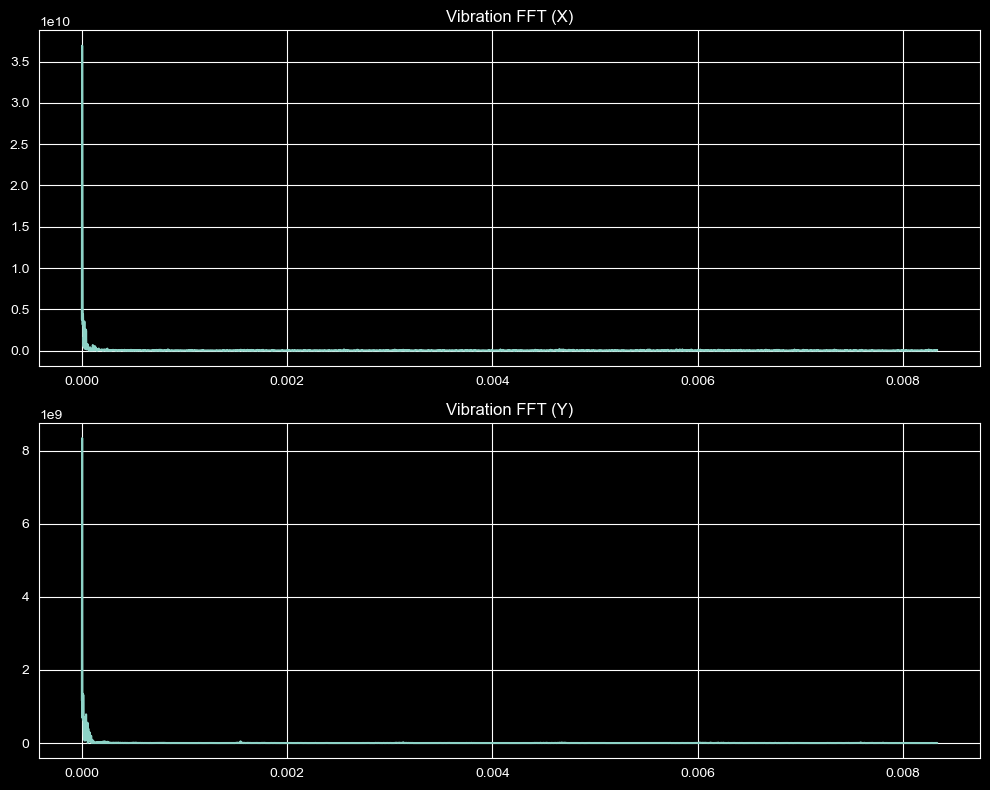

✅ Data saved to: E:\Reverse Telescope Test Data\20260306_data\springgenie\collimated_beam_entry.xlsx


In [3]:
# POST-PROCESSING ONLY (Fixes graphs & Excel)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# CHECK IF DATA EXISTS
if 'dot_x' not in locals():
    raise SystemExit("❌ ERROR: Data not found in memory. You might need to rerun the analysis if the kernel restarted.")
else:
    print("✅ Found existing data in memory. Processing now...")

# CALCULATE & CLEAN (Remove the -10,000 pixel glitches)
# Filter bad data (NaNs)
mask = np.isfinite(dot_x) & np.isfinite(dot_y) & np.isfinite(laser_x) & np.isfinite(laser_y)

# Raw Subtraction
corrected_x_raw = dot_x[mask] - laser_x[mask]
corrected_y_raw = dot_y[mask] - laser_y[mask]

if len(corrected_x_raw) > 0:
    # Recenter first
    mu_x_rel_raw = corrected_x_raw - corrected_x_raw[0]
    mu_y_rel_raw = corrected_y_raw - corrected_y_raw[0]
    
    # FILTER SPIKES
    clean_mask = (np.abs(mu_x_rel_raw) < 500) & (np.abs(mu_y_rel_raw) < 500)
    
    # Apply Filter
    mu_x_rel = mu_x_rel_raw[clean_mask]
    mu_y_rel = mu_y_rel_raw[clean_mask]
    
    # Get matching FWHM data
    fwhm_x_final = dot_fwhm_x[mask][clean_mask]
    fwhm_y_final = dot_fwhm_y[mask][clean_mask]
    
    frames = np.arange(len(mu_x_rel))
    print(f"✅ Data Cleaned. Removed {np.sum(~clean_mask)} glitch frames.")
else:
    print("❌ ERROR: Math failed. All frames were bad.")
    raise SystemExit("Stopping.")

# PLOT 1: POSITION (Cleaned)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axs[0].plot(frames, mu_x_rel, color='blue', label="Corrected X")
axs[0].set_ylabel("X Shift (px)"); axs[0].legend()
axs[0].set_title(f"{foldername}: Laser-Corrected Position (Cleaned)")
axs[1].plot(frames, mu_y_rel, color='green', label="Corrected Y")
axs[1].set_ylabel("Y Shift (px)"); axs[1].set_xlabel("Frame"); axs[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(parent_folder, foldername + "_position_cleaned.png"))
plt.show()

# PLOT 2: FWHM
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axs[0].plot(frames, fwhm_x_final, color='orange', label="FWHM X")
axs[0].set_ylabel("Width (px)"); axs[0].legend()
axs[0].set_title(f"{foldername}: Dot Focus Stability")
axs[1].plot(frames, fwhm_y_final, color='red', label="FWHM Y")
axs[1].set_ylabel("Width (px)"); axs[1].set_xlabel("Frame"); axs[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(parent_folder, foldername + "_FWHM.png"))
plt.show()

# PLOT 3: FFT
def compute_fft(signal, dt):
    fft_vals = np.fft.fft(signal - np.mean(signal))
    freqs = np.fft.fftfreq(len(signal), d=dt)
    mask = freqs > 0
    return freqs[mask], np.abs(fft_vals[mask])**2

frame_rate = 0.016666667  
dt = 1.0 / frame_rate
freqs_x, power_mu_x   = compute_fft(mu_x_rel, dt)
freqs_y, power_mu_y   = compute_fft(mu_y_rel, dt)

fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(freqs_x, power_mu_x)
axs[0].set_title("Vibration FFT (X)")
axs[1].plot(freqs_y, power_mu_y)
axs[1].set_title("Vibration FFT (Y)")
plt.tight_layout()
fig.savefig(os.path.join(parent_folder, foldername + "_FFT.png"))
plt.show()

# 6. SAVE TO EXCEL (Fixed Columns)
csv_path = os.path.join(parent_folder, "collimated_beam_entry.xlsx")

try:
    df = pd.read_excel(csv_path, engine='openpyxl')
except:
    df = pd.DataFrame()

# Metadata
try:
    first_file = os.path.basename(fits_list[0])
    last_file = os.path.basename(fits_list[-1])
    start_t = first_file[-22:-5]
    stop_t = last_file[-22:-5]
except:
    start_t = "Unknown"; stop_t = "Unknown"

# Dictionary with YOUR EXACT COLUMN NAMES
new_row = {
    'filename': foldername,
    'number of frames': len(frames),
    'start time': start_t,
    'stop time': stop_t,
    'notes': "Parallel Analysis (Cleaned)",
    'frame rate': frame_rate,
    'x position': np.nanmean(mu_x_rel),
    'x position std': np.nanstd(mu_x_rel),
    'y position': np.nanmean(mu_y_rel),
    'y position std': np.nanstd(mu_y_rel),
    'FWHM x': np.nanmean(fwhm_x_final),
    'FWHM x std': np.nanstd(fwhm_x_final),
    'FWHM y': np.nanmean(fwhm_y_final),
    'FWHM y std': np.nanstd(fwhm_y_final)
}

df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
try:
    df.to_excel(csv_path, index=False, engine='openpyxl')
    print(f"✅ Data saved to: {csv_path}")
except:
    print("❌ ERROR: Close the Excel file and try again.")

In [4]:
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import os

# VIDEO SETTINGS
DECIMATION = 200  # Skip frames to speed up rendering (Try 5 or 10)
video_indices = np.arange(0, len(fits_list), DECIMATION)
# save_video_path = os.path.join(parent_folder, foldername + "_profile_analysis.mp4")
save_video_path = os.path.join(parent_folder, foldername + "_profile_analysis.gif")

print(f"Initializing Profile Video... ({len(video_indices)} frames)")


fig = plt.figure(figsize=(12, 10))
# Grid: Top-Left (Profiles), Bottom-Right (Image)
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.0, hspace=0.0)

ax_img = fig.add_subplot(gs[1, 0])
ax_x   = fig.add_subplot(gs[0, 0], sharex=ax_img)
ax_y   = fig.add_subplot(gs[1, 1], sharey=ax_img)
fig.add_subplot(gs[0, 1]).axis("off")

# Load first frame to set scaling
with fits.open(fits_list[0]) as hdul:
    first_data = np.flip(hdul[0].data, axis=(0, 1))

# MAIN IMAGE
vmin, vmax = np.percentile(first_data, 1), np.percentile(first_data, 99)
im = ax_img.imshow(first_data, cmap="viridis", origin="lower", vmin=vmin, vmax=vmax, aspect="auto")

# Markers for Dot (Green) and Laser (Red)
dot_mark, = ax_img.plot([], [], 'g+', ms=15, markeredgewidth=2, label="Dot Center")
las_mark, = ax_img.plot([], [], 'rx', ms=15, markeredgewidth=2, label="Laser Center")
ax_img.legend(loc="upper right", fontsize=9, framealpha=0.5)

# X-PROFILE (Top Graph)
profile_x_data = np.sum(first_data, axis=0)
line_x, = ax_x.plot(np.arange(first_data.shape[1]), profile_x_data, 'k-', lw=1)
# Vertical lines showing calculated centers
vline_dot_x = ax_x.axvline(x=0, color='g', linestyle='--', alpha=0.7)
vline_las_x = ax_x.axvline(x=0, color='r', linestyle='--', alpha=0.7)

# Y-PROFILE (Right Graph)
profile_y_data = np.sum(first_data, axis=1)
line_y, = ax_y.plot(profile_y_data, np.arange(first_data.shape[0]), 'k-', lw=1)
# Horizontal lines showing calculated centers
hline_dot_y = ax_y.axhline(y=0, color='g', linestyle='--', alpha=0.7)
hline_las_y = ax_y.axhline(y=0, color='r', linestyle='--', alpha=0.7)

# Formatting axes
ax_x.set_xlim(0, first_data.shape[1])
ax_y.set_ylim(0, first_data.shape[0])
ax_x.tick_params(labelbottom=False)
ax_y.tick_params(labelleft=False)
ax_x.set_ylabel("Sum Counts")
ax_y.set_xlabel("Sum Counts")
ax_x.grid(True, alpha=0.3)
ax_y.grid(True, alpha=0.3)

# Correlation/Deviation
stats_text = ax_img.text(
    0.02, 0.98, "", 
    transform=ax_img.transAxes, 
    color="white", fontsize=12, verticalalignment="top",
    bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=4)
)

# ANIMATION LOOP

def update(frame_idx):
    # 'frame_idx' is the index in our DECIMATED list, not the file index
    real_idx = video_indices[frame_idx]
    
    # Load Data directly 
    try:
        with fits.open(fits_list[real_idx]) as hdul:
            img = np.flip(hdul[0].data, axis=(0, 1))
    except:
        return [im]

    # Update Image
    im.set_array(img)
    
    # Update Profiles
    prof_x = np.sum(img, axis=0)
    prof_y = np.sum(img, axis=1)
    line_x.set_ydata(prof_x)
    line_y.set_xdata(prof_y)
    
    # Auto-scale profile views if intensity changes drastically
    if frame_idx % 20 == 0:
        ax_x.set_ylim(0, np.max(prof_x)*1.1)
        ax_y.set_xlim(0, np.max(prof_y)*1.1)

    # Get Calculated Positions (Using the raw arrays from previous code block)
    # Check if we have valid data for this frame
    dx, dy = dot_x[real_idx], dot_y[real_idx]
    lx, ly = laser_x[real_idx], laser_y[real_idx]
    
    # Update Markers on Image
    dot_mark.set_data([dx], [dy])
    las_mark.set_data([lx], [ly])
    
    # Update Guide Lines on Graphs
    vline_dot_x.set_xdata([dx])
    vline_las_x.set_xdata([lx])
    hline_dot_y.set_ydata([dy])
    hline_las_y.set_ydata([ly])
    
    # Update Text (Correlation)
    if np.isfinite(dx) and np.isfinite(lx):
        shift_x = dx - lx
        shift_y = dy - ly
        msg = (f"Frame: {real_idx}\n"
               f"Dot: ({dx:.1f}, {dy:.1f})\n"
               f"Laser: ({lx:.1f}, {ly:.1f})\n"
               f"-----------------\n"
               f"SHIFT X: {shift_x:.2f} px\n"
               f"SHIFT Y: {shift_y:.2f} px")
    else:
        msg = f"Frame: {real_idx}\n(Fit Failed)"
        
    stats_text.set_text(msg)

    return [im, line_x, line_y, dot_mark, las_mark, 
            vline_dot_x, vline_las_x, hline_dot_y, hline_las_y, stats_text]

# Run Animation
ani = animation.FuncAnimation(fig, update, frames=len(video_indices), interval=50, blit=True)

# Save Video
try:
    print("Saving video")
    # Try FFMPEG first (Faster, better quality)
    writer = animation.FFMpegWriter(fps=30, bitrate=3000)
    ani.save(save_video_path, writer=writer)
except Exception as e:
    print(f"⚠️ FFMPEG failed ({e}). Switching to 'Pillow'")
    ani.save(save_video_path, writer='pillow', fps=30)

print(f"Video Saved: {save_video_path}")
plt.close()

Initializing Profile Video... (71 frames)
Saving video
Video Saved: E:\Reverse Telescope Test Data\20260306_data\springgenie\springgenie_fits_profile_analysis.gif


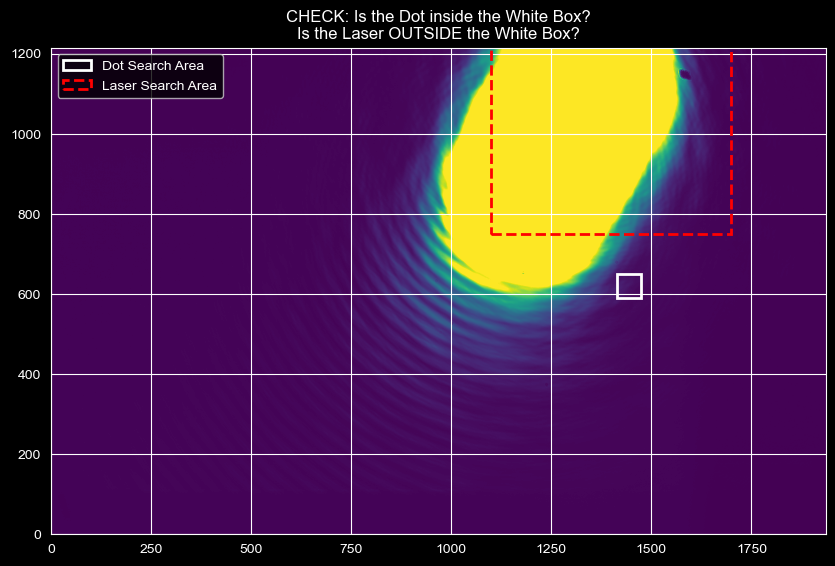

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from astropy.io import fits
import numpy as np

# ==========================================
# NEW TIGHTER COORDINATES (Try these!)
# ==========================================
# I shrank the box from 100px wide to 60px wide to exclude the laser
dot_x_slice = slice(1415, 1475) 
dot_y_slice = slice(590, 650)   

# Keep Laser the same
laser_x_slice = slice(1100, 1700)
laser_y_slice = slice(750, 1300)

# ==========================================
# VISUAL CHECK
# ==========================================
# Open the first file
with fits.open(fits_list[0]) as hdul:
    data = np.flip(hdul[0].data, axis=(0, 1))

fig, ax = plt.subplots(figsize=(10, 10))
# Boost contrast so we can see the faint dot
vmin, vmax = np.percentile(data, 1), np.percentile(data, 99.5)
ax.imshow(data, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)

# Draw the Search Boxes
# Dot Box (White)
rect_dot = patches.Rectangle((dot_x_slice.start, dot_y_slice.start), 
                             dot_x_slice.stop - dot_x_slice.start,
                             dot_y_slice.stop - dot_y_slice.start,
                             linewidth=2, edgecolor='white', facecolor='none', label='Dot Search Area')

# Laser Box (Red)
rect_las = patches.Rectangle((laser_x_slice.start, laser_y_slice.start), 
                             laser_x_slice.stop - laser_x_slice.start,
                             laser_y_slice.stop - laser_y_slice.start,
                             linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='Laser Search Area')

ax.add_patch(rect_dot)
ax.add_patch(rect_las)
ax.legend()
ax.set_title("CHECK: Is the Dot inside the White Box?\nIs the Laser OUTSIDE the White Box?")
plt.show()